In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')
import os

In [17]:
try:
    true_df = pd.read_csv('True.csv', on_bad_lines='skip', engine='python')
    fake_df = pd.read_csv('Fake.csv', on_bad_lines='skip', engine='python')
    print("CSV files loaded successfully, skipping any malformed lines.")
except Exception as e:
    print(f"An error occurred while loading CSV files: {e}")

if 'true_df' in locals() and 'fake_df' in locals():
    true_df['label'] = 0   # REAL  = 0
    fake_df['label'] = 1   # FAKE  = 1

    df = pd.concat([true_df, fake_df], ignore_index=True)

    df['text_length'] = df['text'].astype(str).apply(len)
    df['word_count']  = df['text'].astype(str).apply(lambda x: len(x.split()))

    print("=" * 60)
    print("  DATASET SUMMARY (After handling malformed lines)")
    print("=" * 60)
    print(f"  Total articles : {len(df):,}")
    print(f"  Fake articles  : {len(fake_df):,}  ({len(fake_df)/len(df)*100:.1f}%) -- after skipping bad lines")
    print(f"  Real articles  : {len(true_df):,}  ({len(true_df)/len(df)*100:.1f}%) -- after skipping bad lines")
    print(f"  Features used  : text_length, word_count")
    print(f"  Mean text len (Fake) : {fake_df['text'].astype(str).apply(len).mean():.0f} chars")
    print(f"  Mean text len (Real) : {true_df['text'].astype(str).apply(len).mean():.0f} chars")
    print()
else:
    print("DataFrames could not be loaded due to previous errors.")

CSV files loaded successfully, skipping any malformed lines.
  DATASET SUMMARY (After handling malformed lines)
  Total articles : 44,898
  Fake articles  : 23,481  (52.3%) -- after skipping bad lines
  Real articles  : 21,417  (47.7%) -- after skipping bad lines
  Features used  : text_length, word_count
  Mean text len (Fake) : 2547 chars
  Mean text len (Real) : 2383 chars



In [18]:
FAKE_C  = '#E05252'
REAL_C  = '#5B9BD5'
NAVY    = '#1a1a2e'
BG      = '#FAFAFA'
FONT_T  = dict(fontsize=13, fontweight='bold', color=NAVY)
FONT_A  = dict(fontsize=10, color='#333333')

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(axis='y', color='#DDDDDD', linewidth=0.7, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)

os.makedirs('charts', exist_ok=True)

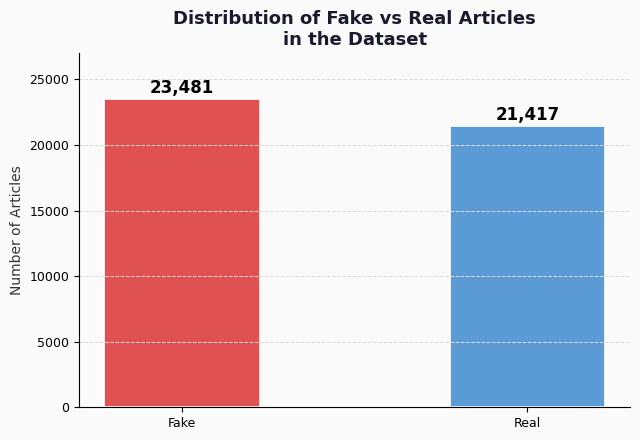

In [19]:
n_fake, n_real = len(fake_df), len(true_df)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(BG)
bars = ax.bar(['Fake', 'Real'], [n_fake, n_real],
              color=[FAKE_C, REAL_C], width=0.45,
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, [n_fake, n_real]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 150,
            f'{val:,}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.set_title('Distribution of Fake vs Real Articles\nin the Dataset', **FONT_T)
ax.set_ylabel('Number of Articles', **FONT_A)
ax.set_ylim(0, max(n_fake, n_real) * 1.15)
style_ax(ax); ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

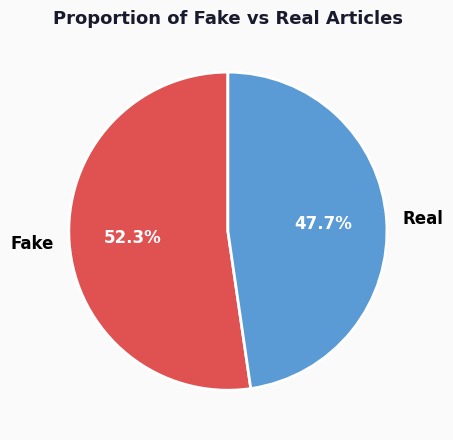

In [20]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.patch.set_facecolor(BG)
wedges, texts, autotexts = ax.pie(
    [n_fake, n_real], labels=['Fake', 'Real'],
    colors=[FAKE_C, REAL_C], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'fontweight': 'bold'})
for at in autotexts:
    at.set_fontsize(12); at.set_color('white')
ax.set_title('Proportion of Fake vs Real Articles', **FONT_T)
plt.tight_layout()
plt.show()

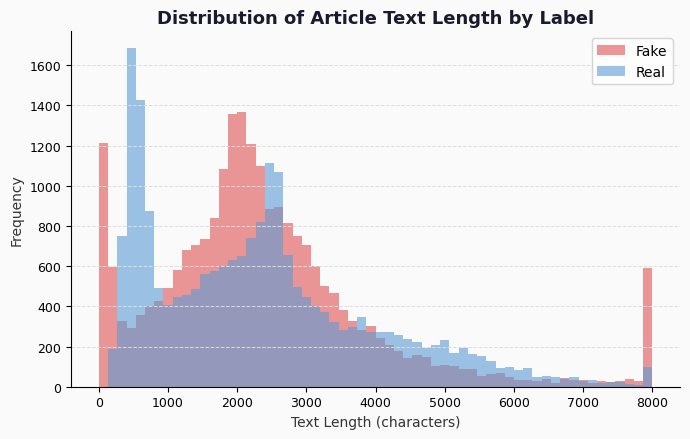

In [21]:
fake_len = fake_df['text'].astype(str).apply(len)
real_len = true_df['text'].astype(str).apply(len)

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(BG)
ax.hist(fake_len.clip(0, 8000), bins=60, color=FAKE_C, alpha=0.6, label='Fake', edgecolor='none')
ax.hist(real_len.clip(0, 8000), bins=60, color=REAL_C, alpha=0.6, label='Real', edgecolor='none')
ax.set_title('Distribution of Article Text Length by Label', **FONT_T)
ax.set_xlabel('Text Length (characters)', **FONT_A)
ax.set_ylabel('Frequency', **FONT_A)
ax.legend(fontsize=10)
style_ax(ax)
plt.tight_layout()
plt.show()

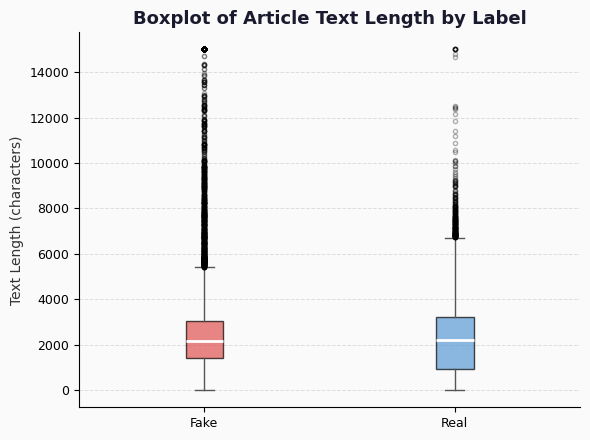

In [22]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.patch.set_facecolor(BG)
bp = ax.boxplot(
    [fake_len.clip(0, 15000), real_len.clip(0, 15000)],
    labels=['Fake', 'Real'], patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3))
bp['boxes'][0].set_facecolor(FAKE_C); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(REAL_C); bp['boxes'][1].set_alpha(0.7)
for w in bp['whiskers'] + bp['caps']:
    w.set_color('#555555')
ax.set_title('Boxplot of Article Text Length by Label', **FONT_T)
ax.set_ylabel('Text Length (characters)', **FONT_A)
style_ax(ax)
plt.tight_layout()
plt.show()

In [23]:
fake_sub = fake_df['subject'].value_counts()
real_sub = true_df['subject'].value_counts()
all_cats = list(set(list(fake_sub.index) + list(real_sub.index)))
x = np.arange(len(all_cats)); w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.bar(x - w/2, [fake_sub.get(c, 0) for c in all_cats], w,
       color=FAKE_C, alpha=0.85, label='Fake', edgecolor='white')
ax.bar(x + w/2, [real_sub.get(c, 0) for c in all_cats], w,
       color=REAL_C, alpha=0.85, label='Real', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(all_cats, rotation=30, ha='right', fontsize=9)
ax.set_title('Distribution of Articles Across Subject Categories', **FONT_T)
ax.set_ylabel('Number of Articles', **FONT_A)
ax.legend(fontsize=10); style_ax(ax)
plt.tight_layout()
plt.close()

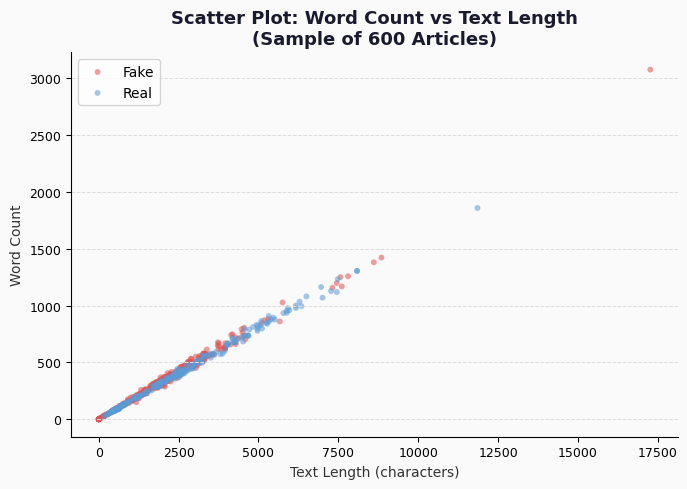

In [24]:
sample = df.sample(600, random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(BG)
for lbl, col, name in [(1, FAKE_C, 'Fake'), (0, REAL_C, 'Real')]:
    s = sample[sample['label'] == lbl]
    ax.scatter(s['text_length'], s['word_count'],
               color=col, alpha=0.55, s=18, label=name, edgecolors='none')
ax.set_title('Scatter Plot: Word Count vs Text Length\n(Sample of 600 Articles)', **FONT_T)
ax.set_xlabel('Text Length (characters)', **FONT_A)
ax.set_ylabel('Word Count', **FONT_A)
ax.legend(fontsize=10); style_ax(ax)
plt.tight_layout()
plt.show()

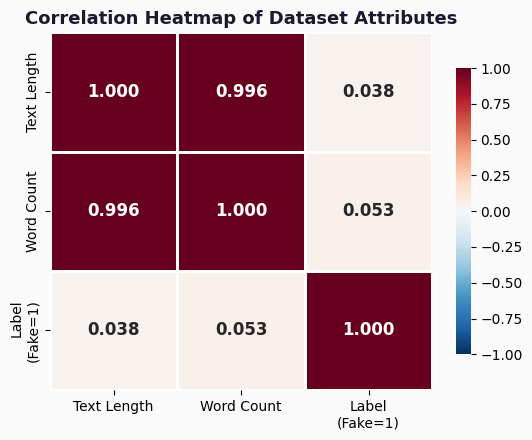

In [25]:
corr = df[['text_length', 'word_count', 'label']].corr()
corr.columns = ['Text Length', 'Word Count', 'Label\n(Fake=1)']
corr.index   = ['Text Length', 'Word Count', 'Label\n(Fake=1)']

fig, ax = plt.subplots(figsize=(5.5, 4.5))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=2, linecolor='white', ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of Dataset Attributes', **FONT_T)
plt.tight_layout()
plt.show()

In [26]:
print()
print("=" * 60)
print("  LOGISTIC REGRESSION — 10-FOLD STRATIFIED K-FOLD CV")
print("=" * 60)

X = df[['text_length', 'word_count']].values
y = df['label'].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

skf     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []
cms     = []

print(f"\n{'Fold':<6} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 52)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx],        y[test_idx]

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)

    results.append({'fold': fold+1, 'accuracy': acc,
                    'precision': prec, 'recall': rec, 'f1': f1})
    cms.append(confusion_matrix(y_te, y_pred))
    print(f"{fold+1:<6} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

res_df = pd.DataFrame(results)
avgs   = res_df[['accuracy', 'precision', 'recall', 'f1']].mean()
print("-" * 52)
print(f"{'Avg':<6} {avgs['accuracy']:<12.4f} {avgs['precision']:<12.4f} "
      f"{avgs['recall']:<12.4f} {avgs['f1']:<12.4f}")
print()


  LOGISTIC REGRESSION — 10-FOLD STRATIFIED K-FOLD CV

Fold   Accuracy     Precision    Recall       F1-Score    
----------------------------------------------------
1      0.6212       0.6403       0.6286       0.6344      
2      0.6267       0.6437       0.6410       0.6423      
3      0.6290       0.6449       0.6465       0.6457      
4      0.6310       0.6502       0.6371       0.6436      
5      0.6385       0.6560       0.6491       0.6525      
6      0.6305       0.6484       0.6410       0.6447      
7      0.6216       0.6390       0.6354       0.6372      
8      0.6327       0.6511       0.6420       0.6465      
9      0.6304       0.6514       0.6312       0.6411      
10     0.6209       0.6419       0.6222       0.6319      
----------------------------------------------------
Avg    0.6282       0.6467       0.6374       0.6420      



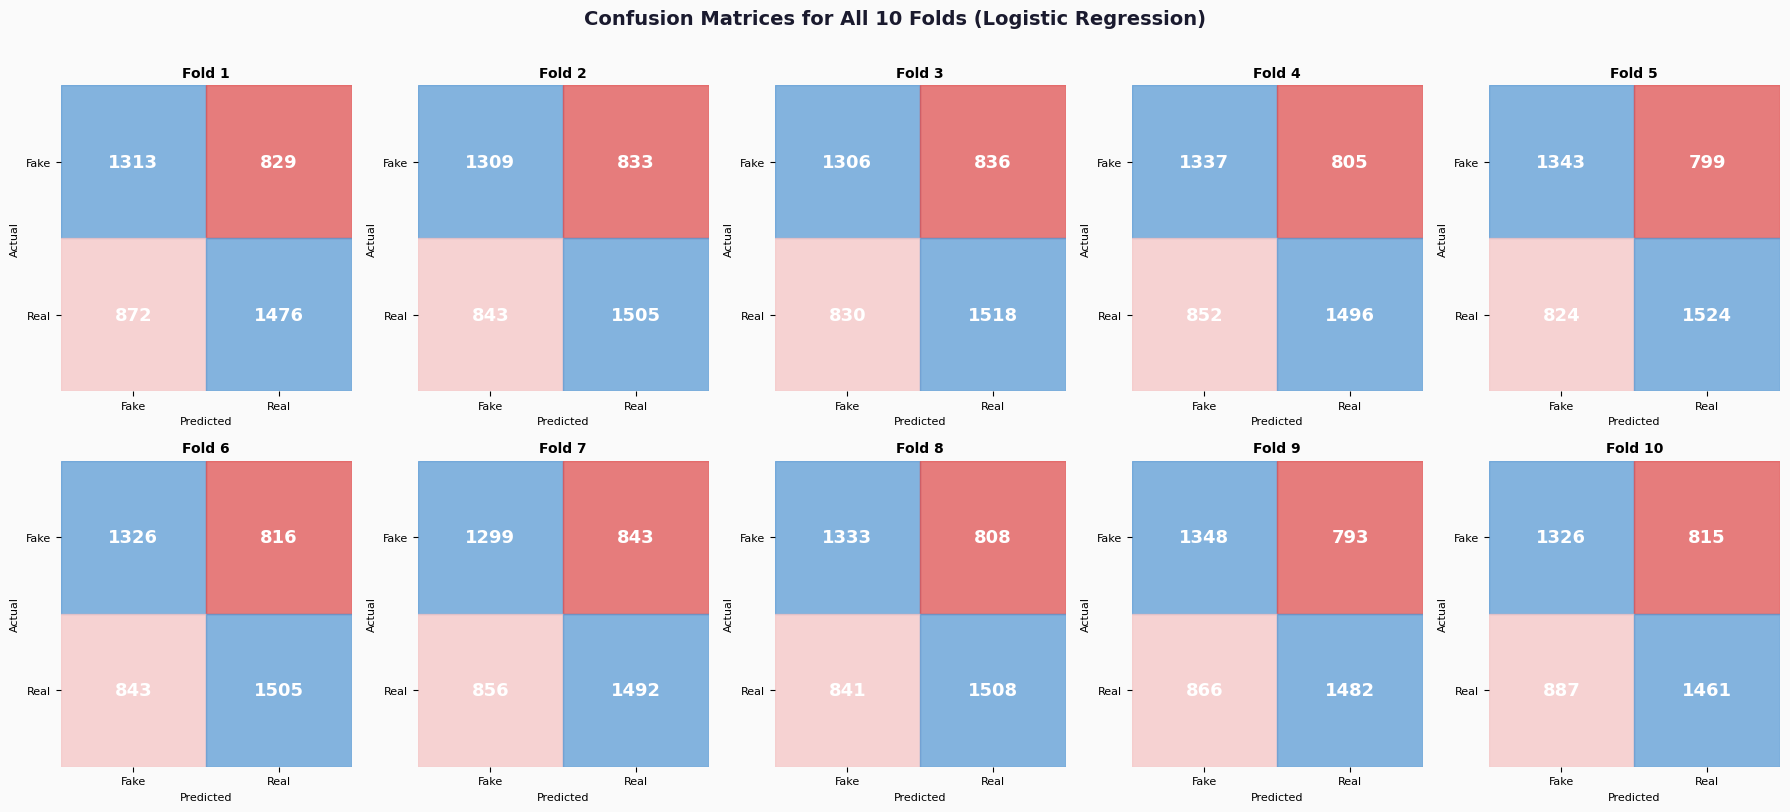

In [27]:
fig = plt.figure(figsize=(18, 8))
fig.patch.set_facecolor(BG)
fig.suptitle('Confusion Matrices for All 10 Folds (Logistic Regression)',
             fontsize=14, fontweight='bold', color=NAVY, y=1.01)

COLORS = [[REAL_C, FAKE_C], ['#f5c5c5', REAL_C]]

for i, cm in enumerate(cms):
    ax = fig.add_subplot(2, 5, i + 1)
    ax.set_facecolor(BG)
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1 - r), 1, 1,
                                        color=COLORS[r][c], alpha=0.75))
            ax.text(c + 0.5, 1 - r + 0.5, str(cm[r, c]),
                    ha='center', va='center',
                    fontsize=13, fontweight='bold', color='white')
    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Fake', 'Real'], fontsize=8)
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Real', 'Fake'], fontsize=8)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual',    fontsize=8)
    ax.set_title(f'Fold {i+1}', fontsize=10, fontweight='bold')
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

plt.tight_layout()
plt.show()

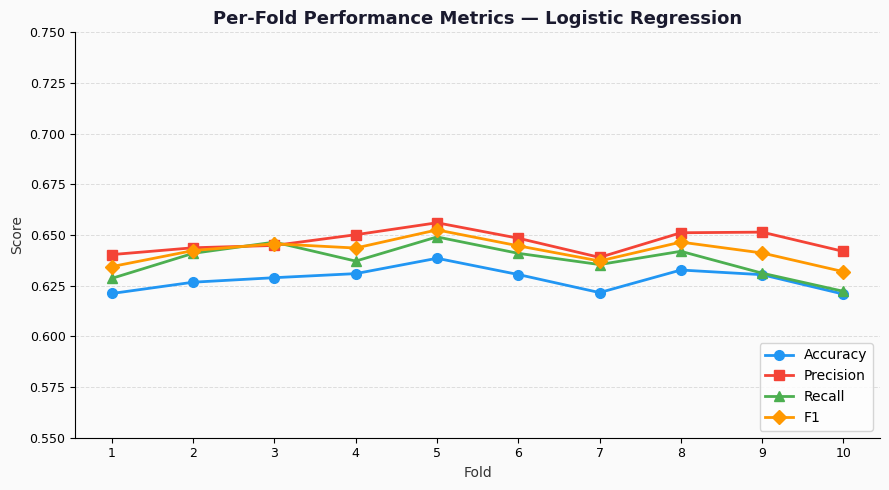

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
folds     = res_df['fold']
style_map = {
    'accuracy':  ('#2196F3', 'o'),
    'precision': ('#F44336', 's'),
    'recall':    ('#4CAF50', '^'),
    'f1':        ('#FF9800', 'D'),
}
for col, (clr, mrk) in style_map.items():
    ax.plot(folds, res_df[col], color=clr, marker=mrk,
            linewidth=2, markersize=7, label=col.capitalize())
ax.set_title('Per-Fold Performance Metrics — Logistic Regression', **FONT_T)
ax.set_xlabel('Fold', **FONT_A)
ax.set_ylabel('Score', **FONT_A)
ax.set_xticks(folds)
ax.set_ylim(0.55, 0.75)
ax.legend(fontsize=10, loc='lower right')
style_ax(ax)
plt.tight_layout()
plt.show()

In [29]:
print()
print("=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Average Accuracy  : {avgs['accuracy']*100:.2f}%")
print(f"  Average Precision : {avgs['precision']*100:.2f}%")
print(f"  Average Recall    : {avgs['recall']*100:.2f}%")
print(f"  Average F1-Score  : {avgs['f1']*100:.2f}%")
print()
print("=" * 60)


  FINAL RESULTS SUMMARY
  Average Accuracy  : 62.82%
  Average Precision : 64.67%
  Average Recall    : 63.74%
  Average F1-Score  : 64.20%

